# 0) Imports

In [1]:
# install the main library YFinance
%pip install yfinance
%pip install plotly
%pip install pandas_datareader
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
# IMPORTS
import numpy as np
import pandas as pd

#Fin Data Sources
import yfinance as yf
import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.express as px

import time
from datetime import date


# 1) Understanding Data-Driven Decisions data pulls

In [4]:
end = date.today()
print(f'Year = {end.year}; month= {end.month}; day={end.day}')

start = date(year=end.year-70, month=end.month, day=end.day)
print(f'Period for indexes: {start} to {end} ')

Year = 2026; month= 9; day=3
Period for indexes: 1956-09-03 to 2026-09-03 


## 1.1) GDP

In [5]:
# Real Potential Gross Domestic Product (GDPPOT), Billions of Chained 2012 Dollars, QUARTERLY
# https://fred.stlouisfed.org/series/GDPPOT
gdppot = pdr.DataReader("GDPPOT", "fred", start=start)

In [6]:
gdppot['gdppot_us_yoy'] = gdppot.GDPPOT/gdppot.GDPPOT.shift(4)-1
gdppot['gdppot_us_qoq'] = gdppot.GDPPOT/gdppot.GDPPOT.shift(1)-1
gdppot.tail(15)

,GDPPOT,gdppot_us_yoy,gdppot_us_qoq
DATE,,,
2023-01-01,22229.482194,0.025405,0.006551
2023-04-01,22377.867950,0.026085,0.006675
2023-07-01,22527.570931,0.026560,0.006690
2023-10-01,22678.156520,0.026867,0.006685
2024-01-01,22828.945411,0.026967,0.006649
2024-04-01,22979.033391,0.026864,0.006574
2024-07-01,23126.896106,0.026604,0.006435
2024-10-01,23271.541687,0.026165,0.006254
2025-01-01,23414.656420,0.025657,0.006150


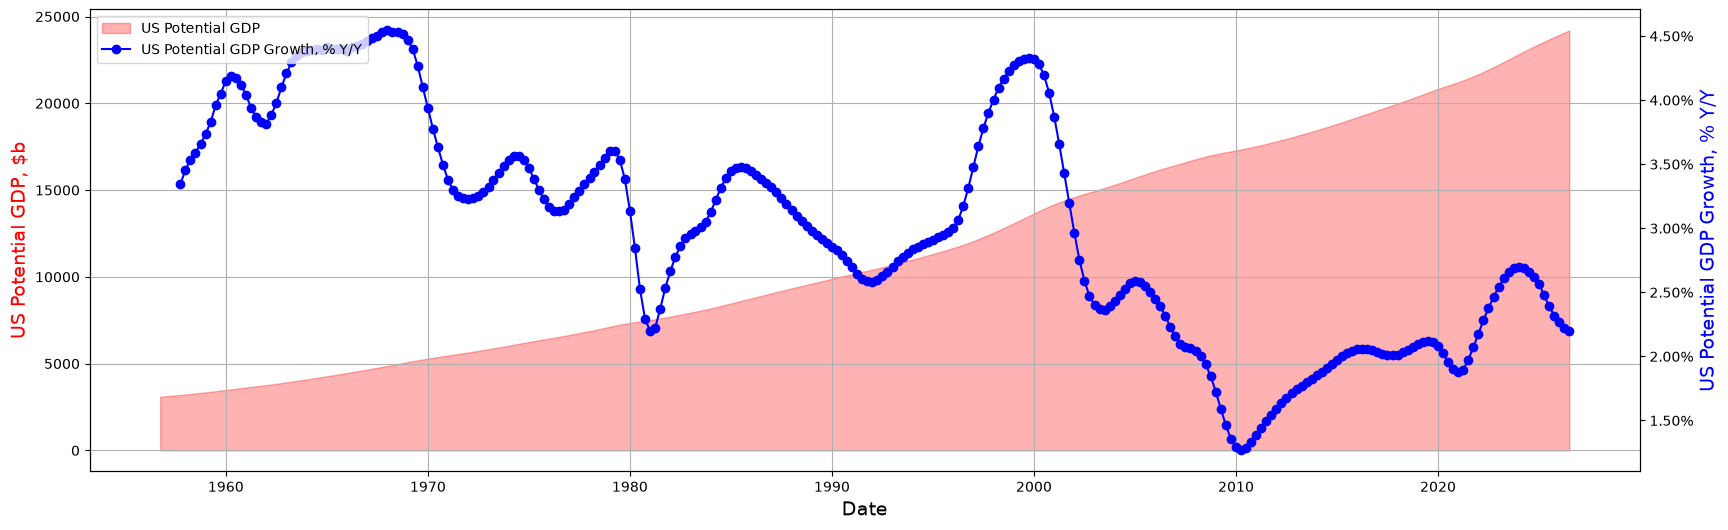

In [7]:
# Visuals GDPPOT
# https://cmdlinetips.com/2019/10/how-to-make-a-plot-with-two-different-y-axis-in-python-with-matplotlib/

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under US potential GDP curve
ax.fill_between(gdppot.index, gdppot.GDPPOT, color="red", alpha=0.3, label="US Potential GDP")

# Creating a secondary y-axis for GDP growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(gdppot.gdppot_us_yoy, color="blue", marker="o", label="US Potential GDP Growth, % Y/Y")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("US Potential GDP, $b", color="red", fontsize=14)
ax2.set_ylabel("US Potential GDP Growth, % Y/Y", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

## 1.2) Inflation - CPI Core

In [8]:
# # "Core CPI index", MONTHLY
# https://fred.stlouisfed.org/series/CPILFESL
# The "Consumer Price Index for All Urban Consumers: All Items Less Food & Energy"
# is an aggregate of prices paid by urban consumers for a typical basket of goods, excluding food and energy.
# This measurement, known as "Core CPI," is widely used by economists because food and energy have very volatile prices.
cpilfesl = pdr.DataReader("CPILFESL", "fred", start=start)

In [9]:
cpilfesl.head()

,CPILFESL
DATE,
1957-01-01,28.5
1957-02-01,28.6
1957-03-01,28.7
1957-04-01,28.8
1957-05-01,28.8


In [10]:
cpilfesl['cpi_core_yoy'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(12)-1
cpilfesl['cpi_core_mom'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(1)-1

cpilfesl.tail(13)

,CPILFESL,cpi_core_yoy,cpi_core_mom
DATE,,,
2025-07-01,328.682,0.030545,0.003125
2025-08-01,329.700,0.031118,0.003097
2025-09-01,330.418,0.030200,0.002178
2025-10-01,NaN,NaN,NaN
2025-11-01,331.043,0.025990,NaN
2025-12-01,331.814,0.026465,0.002329
2026-01-01,332.793,0.025120,0.002950
2026-02-01,333.512,0.024725,0.002161
2026-03-01,334.165,0.026022,0.001958


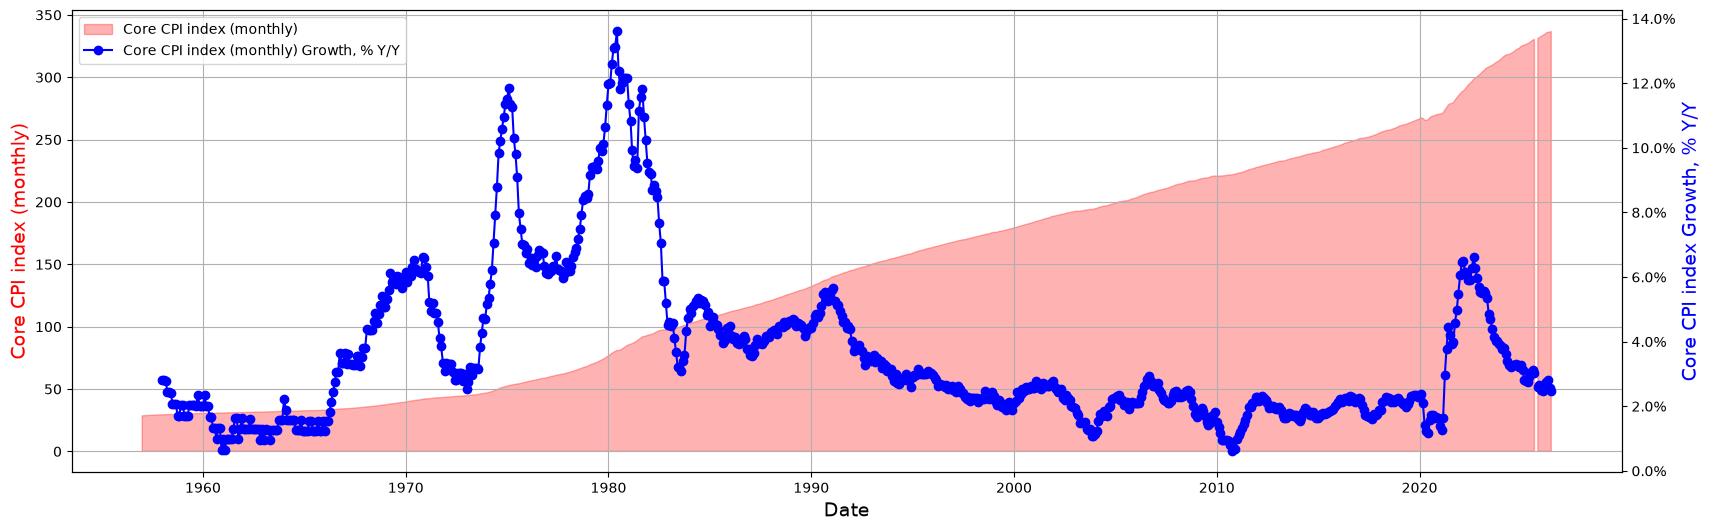

In [11]:
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under CPI
ax.fill_between(cpilfesl.index, cpilfesl.CPILFESL, color="red", alpha=0.3, label="Core CPI index (monthly)")

# Creating a secondary y-axis for CPI growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(cpilfesl.cpi_core_yoy, color="blue", marker="o", label="Core CPI index (monthly) Growth, % Y/Y")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Core CPI index (monthly)", color="red", fontsize=14)
ax2.set_ylabel("Core CPI index Growth, % Y/Y", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

## 1.3 Interest rates

In [12]:
# Fed rate https://fred.stlouisfed.org/series/FEDFUNDS
fedfunds = pdr.DataReader("FEDFUNDS", "fred", start=start)
fedfunds.tail(10)

,FEDFUNDS
DATE,
2025-11-01,3.88
2025-12-01,3.72
2026-01-01,3.64
2026-02-01,3.64
2026-03-01,3.64
2026-04-01,3.64
2026-05-01,3.63
2026-06-01,3.63
2026-07-01,3.63


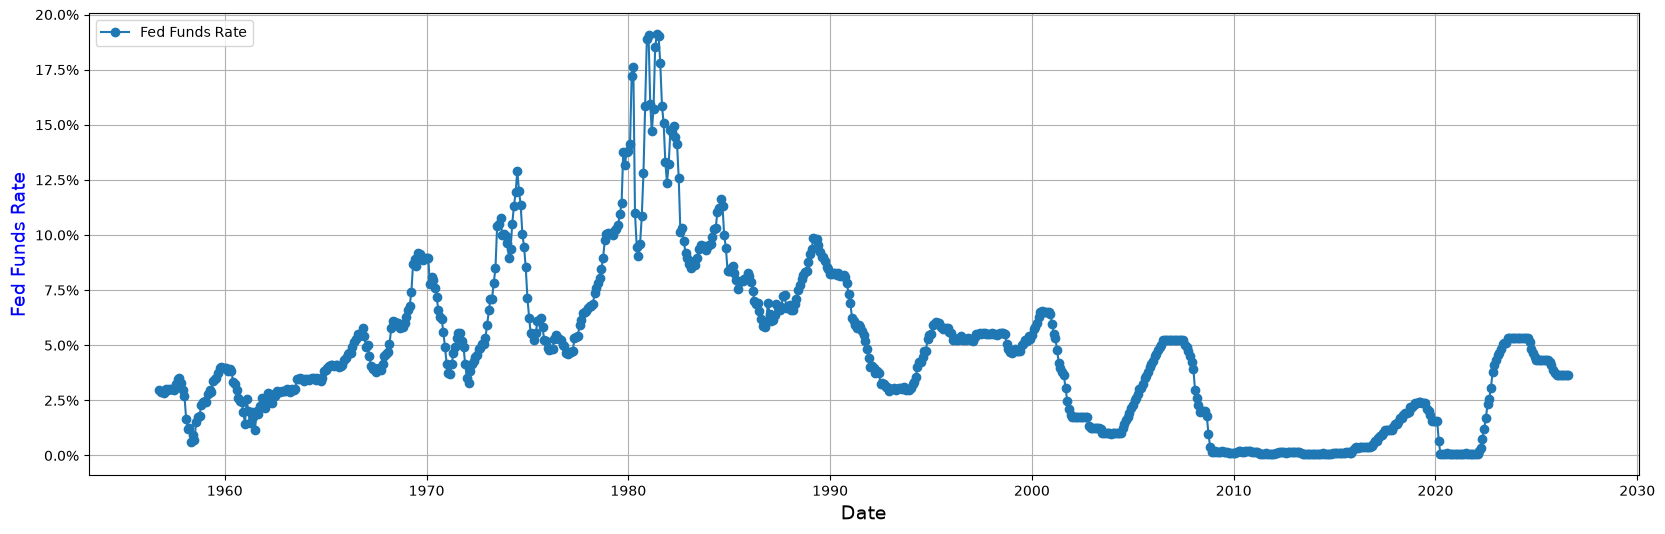

In [13]:
# Fed Funds
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under US potential GDP curve
# ax.fill_between(fedfunds.index, fedfunds.FEDFUNDS, color="red", alpha=0.3, label="Core CPI index (monthly)")

# # Creating a secondary y-axis for GDP growth percentage
# ax2 = ax.twinx()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.plot(fedfunds.index, fedfunds.FEDFUNDS/100, marker="o", label="Fed Funds Rate")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Fed Funds Rate", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

plt.show()

In [14]:
# https://fred.stlouisfed.org/series/DGS1
dgs1 = pdr.DataReader("DGS1", "fred", start=start)
dgs1.tail()

,DGS1
DATE,
2026-08-27,4.04
2026-08-28,4.15
2026-08-31,4.16
2026-09-01,4.18
2026-09-02,4.16


Other rates for US Treasury: https://fred.stlouisfed.org/categories/115  
* https://fred.stlouisfed.org/series/DGS2
* https://fred.stlouisfed.org/series/DGS3
* https://fred.stlouisfed.org/series/DGS5
* https://fred.stlouisfed.org/series/DGS10
...

In [15]:
# https://fred.stlouisfed.org/series/DGS5
dgs5 = pdr.DataReader("DGS5", "fred", start=start)
dgs5.tail()

,DGS5
DATE,
2026-08-27,4.38
2026-08-28,4.48
2026-08-31,4.49
2026-09-01,4.55
2026-09-02,4.54


## 1.4 SNP500

In [16]:
import yfinance as yf

# Other indexes: https://stooq.com/t/ ; https://stooq.com/t/?i=510  --main indexes
# USED TO BE ABLE TO GET DATA FROM STOOQ USING PDR - NOW, WE USE YAHOO FINANCE
# https://pandas-datareader.readthedocs.io/en/latest/remote_data.html


# SPX= S&P500
ticker_obj = yf.Ticker("^SPX")
spx_index = ticker_obj.history(start=start, end=end)
spx_index.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-27 00:00:00-04:00,7710.339844,7741.270020,7689.890137,7730.990234,4362240000,0.0,0.0
2026-08-28 00:00:00-04:00,7735.169922,7771.479980,7700.910156,7711.759766,4297560000,0.0,0.0
2026-08-31 00:00:00-04:00,7697.520020,7697.520020,7665.060059,7686.140137,5386090000,0.0,0.0
2026-09-01 00:00:00-04:00,7635.470215,7663.629883,7611.200195,7631.470215,4858180000,0.0,0.0
2026-09-02 00:00:00-04:00,7634.580078,7681.189941,7633.620117,7666.600098,4738910000,0.0,0.0


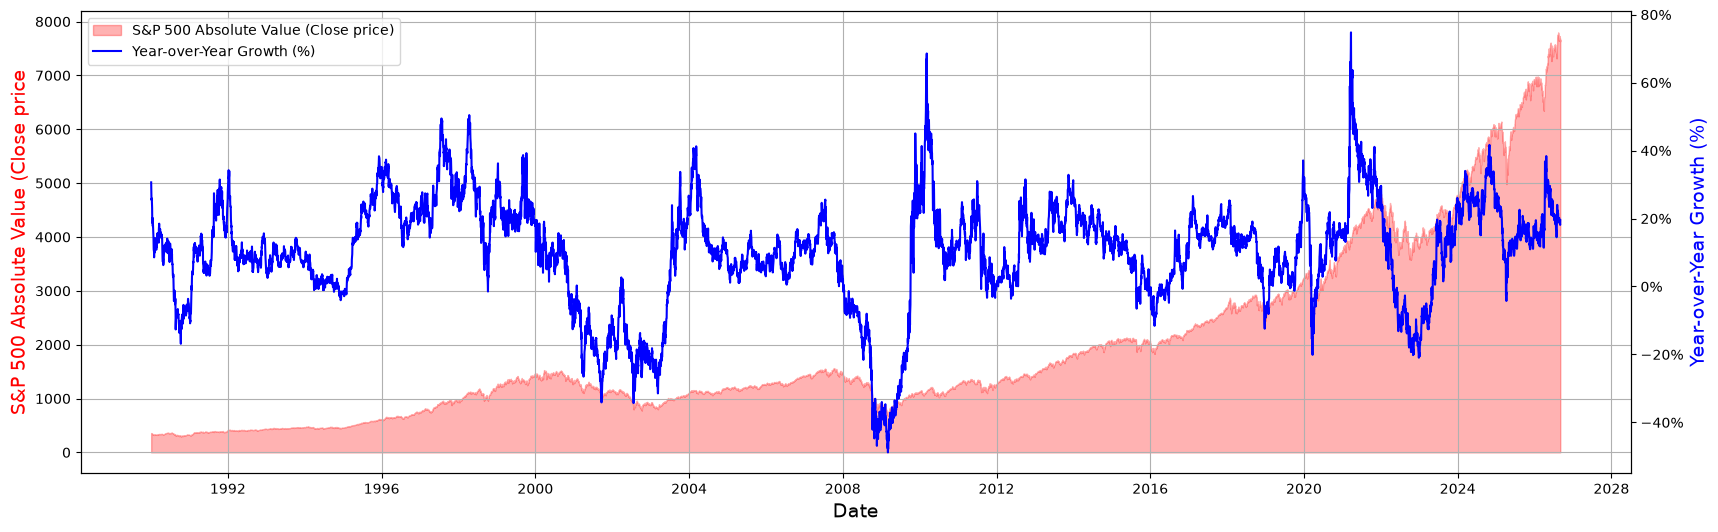

In [17]:
spx_index['spx_yoy'] = (spx_index.Close / spx_index.Close.shift(252)) - 1

# Re-truncate the DataFrame after recalculating 'spx_yoy' to ensure data consistency
spx_truncated = spx_index[spx_index.index>='1990-01-01']

# S&P500 abs. vs. relative growth
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under S&P 500 Close price
ax.fill_between(spx_truncated.index, spx_truncated.Close, color="red", alpha=0.3, label="S&P 500 Absolute Value (Close price)")

# Creating a secondary y-axis for S&P 500 year-over-year growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(spx_truncated.spx_yoy,
         color="blue",
        #  marker=".",
         label="Year-over-Year Growth (%)")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("S&P 500 Absolute Value (Close price", color="red", fontsize=14)
ax2.set_ylabel("Year-over-Year Growth (%)", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

# 2) Data Sources for Stocks

## 2.1 OHLCV data daily - INDEXES

In [18]:
# INDEXES from Yahoo Finance
# DAX index (XETRA - XETRA Delayed Price. Currency in EUR)
# WEB: https://finance.yahoo.com/quote/%5EGDAXI
# Option 1: dax_daily = yf.download(tickers = ["^GDAXI"],
#                      period = "max",
#                      interval = "1d")

# Option 2 (preferred):
# Download data with Adj Close for more accurate price reflections
ticker_obj = yf.Ticker("^GDAXI")
dax_daily = ticker_obj.history(start = start)

In [19]:
dax_daily.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-27 00:00:00+02:00,26354.369141,26402.810547,26241.769531,26367.240234,49230700,0.0,0.0
2026-08-28 00:00:00+02:00,26494.609375,26618.740234,26467.359375,26569.990234,45045000,0.0,0.0
2026-08-31 00:00:00+02:00,26464.140625,26471.789062,26249.589844,26258.109375,81710600,0.0,0.0
2026-09-01 00:00:00+02:00,26150.750000,26206.130859,25916.759766,25970.109375,48552400,0.0,0.0
2026-09-02 00:00:00+02:00,25886.669922,25924.210938,25727.929688,25839.330078,47864100,0.0,0.0


In [20]:
# normally 252 trading days
dax_daily['adj_close_last_year'] = dax_daily['Close'].shift(252)
dax_daily['yoy_growth'] = dax_daily['Close'] / dax_daily['adj_close_last_year'] -1

In [21]:
dax_daily

,Open,High,Low,Close,Volume,Dividends,Stock Splits,adj_close_last_year,yoy_growth
Date,,,,,,,,,
1987-12-30 00:00:00+01:00,1005.190002,1005.190002,1005.190002,1005.190002,0,0.0,0.0,NaN,NaN
1988-01-04 00:00:00+01:00,956.489990,956.489990,956.489990,956.489990,0,0.0,0.0,NaN,NaN
1988-01-05 00:00:00+01:00,996.099976,996.099976,996.099976,996.099976,0,0.0,0.0,NaN,NaN
1988-01-06 00:00:00+01:00,1006.010010,1006.010010,1006.010010,1006.010010,0,0.0,0.0,NaN,NaN
1988-01-07 00:00:00+01:00,1014.469971,1014.469971,1014.469971,1014.469971,0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2026-08-27 00:00:00+02:00,26354.369141,26402.810547,26241.769531,26367.240234,49230700,0.0,0.0,24039.919922,0.096811
2026-08-28 00:00:00+02:00,26494.609375,26618.740234,26467.359375,26569.990234,45045000,0.0,0.0,23902.210938,0.111612
2026-08-31 00:00:00+02:00,26464.140625,26471.789062,26249.589844,26258.109375,81710600,0.0,0.0,24037.330078,0.092389


<Axes: xlabel='Date'>

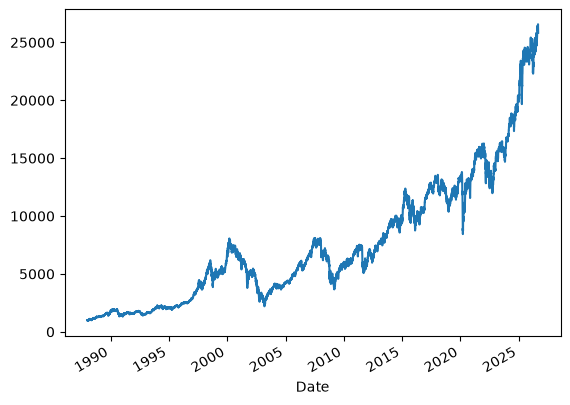

In [22]:
dax_daily['Close'].plot.line()

In [23]:
# delayed 15 min : https://finance.yahoo.com/quote/%5ESPX/
# S&P 500 INDEX : Chicago Options - Chicago Options Delayed Price. Currency in USD
ticker_obj = yf.Ticker("^SPX")
snp500_daily = ticker_obj.history(start = start, interval = "1d")

# old version:
# snp500_daily = yf.download(tickers = "^SPX",
#                      period = "max",
#                      interval = "1d")

In [24]:
snp500_daily.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-28 00:00:00-04:00,7735.169922,7771.479980,7700.910156,7711.759766,4297560000,0.0,0.0
2026-08-31 00:00:00-04:00,7697.520020,7697.520020,7665.060059,7686.140137,5386090000,0.0,0.0
2026-09-01 00:00:00-04:00,7635.470215,7663.629883,7611.200195,7631.470215,4858180000,0.0,0.0
2026-09-02 00:00:00-04:00,7634.580078,7681.189941,7633.620117,7666.600098,4738910000,0.0,0.0
2026-09-03 00:00:00-04:00,7686.709961,7756.759766,7686.709961,7747.709961,2743361691,0.0,0.0


In [25]:
# https://finance.yahoo.com/quote/%5EGSPC/
# SNP - SNP Real Time Price. Currency in USD
# https://www.investopedia.com/insights/introduction-to-stock-market-indices/

ticker_obj = yf.Ticker("^GSPC")
snp500_daily_non_delayed = ticker_obj.history(start = start, interval = "1d")

# old version:
# snp500_daily_non_delayed = yf.download(tickers = "^GSPC",
#                      period = "max",
#                      interval = "1d")

In [26]:
snp500_daily_non_delayed.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-28 00:00:00-04:00,7735.169922,7771.479980,7700.910156,7711.759766,4297560000,0.0,0.0
2026-08-31 00:00:00-04:00,7697.520020,7697.520020,7665.060059,7686.140137,5386090000,0.0,0.0
2026-09-01 00:00:00-04:00,7635.470215,7663.629883,7611.200195,7631.470215,4858180000,0.0,0.0
2026-09-02 00:00:00-04:00,7634.580078,7681.189941,7633.620117,7666.600098,4738910000,0.0,0.0
2026-09-03 00:00:00-04:00,7686.709961,7756.759766,7686.709961,7747.709961,2695072000,0.0,0.0


In [27]:
# Dow Jones Industrial Average: https://finance.yahoo.com/quote/%5EDJI?.tsrc=fin-srch

ticker_obj = yf.Ticker("^DJI")
dji_daily = ticker_obj.history(start = start, interval = "1d")

# dji_daily = yf.download(tickers = "^DJI",
#                      period = "max",
#                      interval = "1d")

## 2.2 OHLCV data daily - ETFs

In [28]:
# https://finance.yahoo.com/quote/VOO?.tsrc=fin-srch

ticker_obj = yf.Ticker("VOO")
voo_etf = ticker_obj.history(start = start, interval = "1d")

# voo_etf = yf.download(tickers = "VOO",
#                      period = "max",
#                      interval = "1d")


In [29]:
voo_etf.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2026-08-28 00:00:00-04:00,709.390015,712.669983,706.260010,707.239990,8084500,0.0,0.0,0.0
2026-08-31 00:00:00-04:00,705.359985,705.940002,702.960022,704.890015,5733400,0.0,0.0,0.0
2026-09-01 00:00:00-04:00,700.450012,702.909973,698.140015,700.280029,6486900,0.0,0.0,0.0
2026-09-02 00:00:00-04:00,700.849976,704.530029,700.179993,703.409973,7742300,0.0,0.0,0.0
2026-09-03 00:00:00-04:00,NaN,NaN,NaN,NaN,8582266,0.0,0.0,0.0


In [30]:
# ETFs
# WisdomTree India Earnings Fund (EPI)
# NYSEArca - Nasdaq Real Time Price. Currency in USD
# WEB: https://finance.yahoo.com/quote/EPI/history?p=EPI

ticker_obj = yf.Ticker("EPI")
epi_etf_daily = ticker_obj.history(start = start, interval = "1d")

# epi_etf_daily = yf.download(tickers = "EPI",
#                      period = "max",
#                      interval = "1d")

In [31]:
epi_etf_daily.head()
print(epi_etf_daily.shape)

(4661, 8)


In [32]:
# find dividends impact on Close vs. Adj.Close
epi_etf_daily[epi_etf_daily.Dividends>0].tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2021-12-27 00:00:00-05:00,33.577710,33.801812,33.577710,33.764462,379100,0.192,0.0,0.0
2022-03-25 00:00:00-04:00,33.563275,33.666313,33.432129,33.666313,584400,0.115,0.0,0.0
2022-06-24 00:00:00-04:00,29.420325,29.778746,29.370545,29.768789,387900,1.845,0.0,0.0
2023-06-26 00:00:00-04:00,34.020314,34.070182,33.960471,33.990395,634600,0.060,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0


In [33]:
epi_etf_daily[(epi_etf_daily.index >='2024-12-23') & (epi_etf_daily.index <='2024-12-28')]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


In [34]:
# find dividends - diff for Close vs. Adj Close
# Open/Close for 06-25 diff is close to divs = 1.845 (~1.58 for Open and 1.3 for Close)
# HELP: https://help.yahoo.com/kb/SLN28256.html#:~:text=Adjusted%20close%20is%20the%20closing,Security%20Prices%20(CRSP)%20standards.
epi_etf_daily[(epi_etf_daily.index >='2024-12-23') & (epi_etf_daily.index <='2024-12-28')]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


In [35]:
# Previous option : no Div. dates , same stats
epi_etf_daily2 = yf.download(tickers = "EPI",
                     period = "max",
                     interval = "1d")

/var/folders/3f/nmjtb9_d3kv620bthjqvt0v80000gn/T/ipykernel_9996/3463259538.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  epi_etf_daily2 = yf.download(tickers = "EPI",
[*********************100%***********************]  1 of 1 completed


In [36]:
epi_etf_daily2[epi_etf_daily2.index>='2024-12-23'].head()

Price,Close,High,Low,Open,Volume
Ticker,EPI,EPI,EPI,EPI,EPI
Date,,,,,
2024-12-23,45.869080,45.879052,45.609761,45.609761,630400
2024-12-24,45.899002,45.928922,45.709503,45.719475,277100
2024-12-26,45.820000,45.840000,45.700001,45.840000,685600
2024-12-27,45.639999,45.650002,45.500000,45.570000,774900
2024-12-30,45.090000,45.180000,44.980000,45.180000,1442100


<Axes: title={'center': "EPI's etf stock price"}, xlabel='Date'>

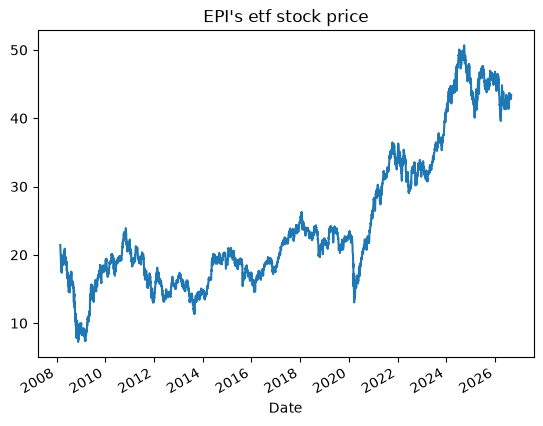

In [37]:
# About yFinance: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html

epi_etf_daily['Close'].plot(title="EPI's etf stock price")

In [38]:
# get actions, incl. dividends - as a dataFrame
epi = yf.Ticker('EPI')
epi.get_actions()

,Dividends,Stock Splits,Capital Gains
Date,,,
2008-12-22 00:00:00-05:00,0.091,0.0,0.0
2009-03-23 00:00:00-04:00,0.007,0.0,0.0
2009-06-22 00:00:00-04:00,0.002,0.0,0.0
2009-09-21 00:00:00-04:00,0.045,0.0,0.0
2009-12-21 00:00:00-05:00,0.006,0.0,0.0
2010-06-28 00:00:00-04:00,0.065,0.0,0.0
2010-09-20 00:00:00-04:00,0.065,0.0,0.0
2010-12-22 00:00:00-05:00,0.013,0.0,0.0
2011-06-22 00:00:00-04:00,0.062,0.0,0.0


In [39]:
# get dividends as Series
epi.get_dividends()

Date
2008-12-22 00:00:00-05:00    0.091
2009-03-23 00:00:00-04:00    0.007
2009-06-22 00:00:00-04:00    0.002
2009-09-21 00:00:00-04:00    0.045
2009-12-21 00:00:00-05:00    0.006
2010-06-28 00:00:00-04:00    0.065
2010-09-20 00:00:00-04:00    0.065
2010-12-22 00:00:00-05:00    0.013
2011-06-22 00:00:00-04:00    0.062
2011-09-26 00:00:00-04:00    0.098
2012-03-26 00:00:00-04:00    0.010
2012-06-25 00:00:00-04:00    0.045
2012-09-24 00:00:00-04:00    0.083
2012-12-24 00:00:00-05:00    0.024
2013-06-24 00:00:00-04:00    0.068
2013-09-23 00:00:00-04:00    0.063
2014-03-24 00:00:00-04:00    0.099
2014-06-23 00:00:00-04:00    0.059
2014-09-22 00:00:00-04:00    0.068
2015-03-23 00:00:00-04:00    0.031
2015-06-22 00:00:00-04:00    0.067
2015-09-21 00:00:00-04:00    0.116
2015-12-21 00:00:00-05:00    0.024
2016-03-21 00:00:00-04:00    0.010
2016-06-20 00:00:00-04:00    0.125
2016-09-26 00:00:00-04:00    0.070
2016-12-23 00:00:00-05:00    0.006
2017-03-27 00:00:00-04:00    0.075
2017-06-26 00:0

In [40]:
# India's stock example
# https://www.nseindia.com/market-data/live-equity-market
EICHERMOT = yf.download(tickers = "EICHERMOT.NS",
                     period = "max",
                     interval = "1d")

/var/folders/3f/nmjtb9_d3kv620bthjqvt0v80000gn/T/ipykernel_9996/1576332518.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  EICHERMOT = yf.download(tickers = "EICHERMOT.NS",
[*********************100%***********************]  1 of 1 completed


In [41]:
EICHERMOT

Price,Close,High,Low,Open,Volume
Ticker,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS
Date,,,,,
1996-01-01,1.119487,1.119487,1.119487,1.119487,22000
1996-01-02,1.122596,1.131926,1.119487,1.119487,31000
1996-01-03,1.135035,1.135035,1.135035,1.135035,11000
1996-01-04,1.135035,1.135035,1.119487,1.119487,16000
1996-01-05,1.119487,1.135035,1.100829,1.135035,6000
...,...,...,...,...,...
2026-08-28,8059.000000,8140.000000,8003.000000,8140.000000,337007
2026-08-31,7953.500000,8030.000000,7941.500000,8000.000000,742794


## 2.3 Paid data - Poligon.io (news endpoint) and Alpha Vantage

In [42]:
# [Polygon.io] Please read the article (section "Polygon.io News API"): https://pythoninvest.com/long-read/chatgpt-api-for-financial-news-summarization
# Endpoint: https://polygon.io/docs/stocks/get_v2_reference_news

In [43]:
# [Alpha Vantage] Please read the article (section "Data Sources"): https://pythoninvest.com/long-read/stock-screening-using-paid-data
# Endpoint: https://www.alphavantage.co/documentation/#fundamentals

## 2.4 Macroeconomics

* some indicator examples: gold reserves vs. volatility

In [44]:
# Gold reserves excl. gold for China
# https://fred.stlouisfed.org/series/TRESEGCNM052N

In [45]:
gold_reserves = pdr.DataReader("TRESEGCNM052N", "fred", start=start)

<Axes: xlabel='DATE'>

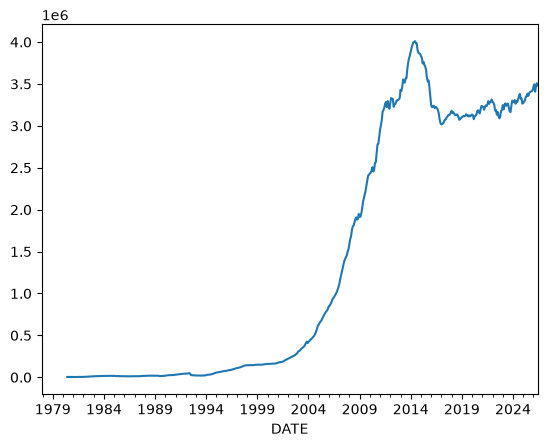

In [46]:
gold_reserves.TRESEGCNM052N.plot.line()

In [47]:
#  CBOE Gold ETF Volatility Index (GVZCLS)
# https://fred.stlouisfed.org/series/GVZCLS
gold_volatility = pdr.DataReader("GVZCLS", "fred", start=start)

<Axes: xlabel='DATE'>

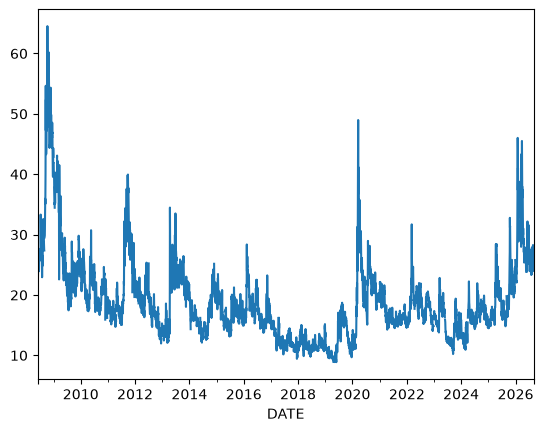

In [48]:
gold_volatility.GVZCLS.plot.line()

In [49]:
#  Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma (DCOILWTICO)
# https://fred.stlouisfed.org/series/DCOILWTICO
oil_wti = pdr.DataReader("DCOILWTICO", "fred", start=start)

<Axes: xlabel='DATE'>

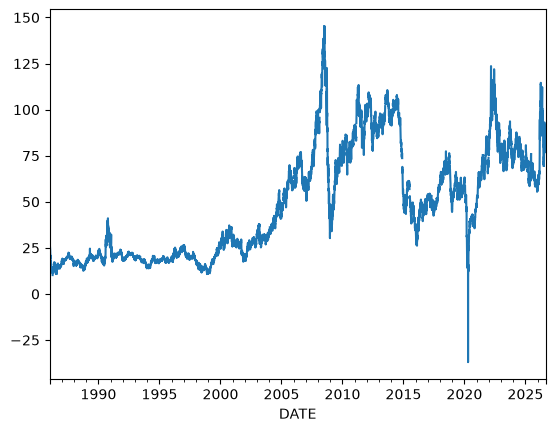

In [50]:
# there is a bug in the data? negative price?
oil_wti.DCOILWTICO.plot.line()

In [51]:
# Crude Oil Prices: Brent - Europe (DCOILBRENTEU)
# https://fred.stlouisfed.org/series/DCOILBRENTEU
oil_brent = pdr.DataReader("DCOILBRENTEU", "fred", start=start)

<Axes: xlabel='DATE'>

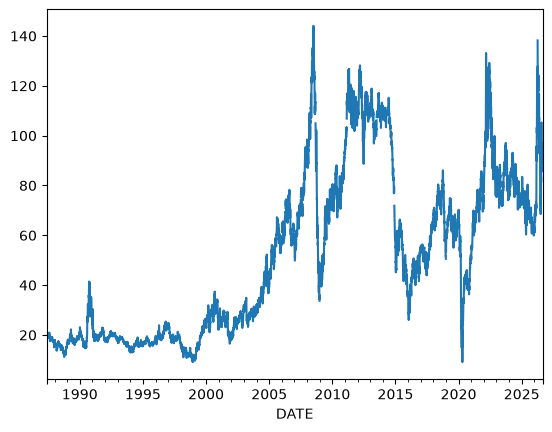

In [52]:
oil_brent.DCOILBRENTEU.plot.line()

In [53]:
# Web Scraping for Macro
# can't call directly via pd.read_html() as it returns 403 (forbidden) --> need to do a bit of work, but still no Selenium
# https://tradingeconomics.com/united-states/indicators
import requests
from bs4 import BeautifulSoup


url = "https://tradingeconomics.com/united-states/indicators"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

response = requests.get(url, headers=headers)

In [54]:

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # You need to be able to find this table tag and read all behind it
    # Find the div with class "table-responsive"
    table_div = soup.find("div", class_="table-responsive")

    # Extract the table within the div
    table = table_div.find("table")

    # Use pandas to read the table into a DataFrame
    df = pd.read_html(str(table))[0]  # Assuming there's only one table, otherwise, loop through the list

    # Display the DataFrame
    print(df)
else:
    print("Failed to retrieve data from the webpage.")

                  Unnamed: 0     Last  Previous  Highest    Lowest  \
0                   Currency    98.98     98.98   165.00     70.70   
1               Stock Market  7744.00   7748.00  7817.00      4.40   
2            GDP Growth Rate     1.50      2.10    34.90    -28.00   
3     GDP Annual Growth Rate     2.10      2.70    13.40     -7.40   
4          Unemployment Rate     4.10      4.20    14.80      2.50   
5          Non Farm Payrolls   -23.00     20.00  4631.00 -20469.00   
6             Inflation Rate     3.40      3.50    23.70    -15.80   
7         Inflation Rate MoM     0.10     -0.40     2.00     -1.80   
8              Interest Rate     3.75      3.75    20.00      0.25   
9           Balance of Trade   -88.58    -71.18     1.95   -133.00   
10           Current Account  -227.00   -221.00     9.96   -438.00   
11    Current Account to GDP    -3.60     -4.00     0.20     -6.00   
12    Government Debt to GDP   123.00    122.00   126.00     31.80   
13         Governmen

/var/folders/3f/nmjtb9_d3kv620bthjqvt0v80000gn/T/ipykernel_9996/51921383.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]  # Assuming there's only one table, otherwise, loop through the list


In [55]:
df

,Unnamed: 0,Last,Previous,Highest,Lowest,Unnamed: 5,Unnamed: 6
0,Currency,98.98,98.98,165.00,70.70,NaN,Sep/26
1,Stock Market,7744.00,7748.00,7817.00,4.40,points,Sep/26
2,GDP Growth Rate,1.50,2.10,34.90,-28.00,percent,Jun/26
3,GDP Annual Growth Rate,2.10,2.70,13.40,-7.40,percent,Jun/26
4,Unemployment Rate,4.10,4.20,14.80,2.50,percent,Jul/26
5,Non Farm Payrolls,-23.00,20.00,4631.00,-20469.00,Thousand,Jul/26
6,Inflation Rate,3.40,3.50,23.70,-15.80,percent,Jul/26
7,Inflation Rate MoM,0.10,-0.40,2.00,-1.80,percent,Jul/26
8,Interest Rate,3.75,3.75,20.00,0.25,percent,Aug/26
9,Balance of Trade,-88.58,-71.18,1.95,-133.00,USD Billion,Jul/26


## 2.5) Financial reporting - EDGAR (in Yahoo)

In [56]:
# let's check for NVDA
nvda =  yf.Ticker('NVDA')

In [57]:
# yearly financials for the last 4 years
nvda.financials


,2026-01-31,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Tax Effect Of Unusual Items,0.000000e+00,0.000000e+00,0.000000e+00,-2.841300e+08,NaN
Tax Rate For Calcs,1.511700e-01,1.326490e-01,1.200000e-01,2.100000e-01,NaN
Normalized EBITDA,1.445520e+11,8.613700e+10,3.558300e+10,7.339000e+09,NaN
Total Unusual Items,NaN,0.000000e+00,0.000000e+00,-1.353000e+09,0.0
Total Unusual Items Excluding Goodwill,NaN,0.000000e+00,0.000000e+00,-1.353000e+09,0.0
Net Income From Continuing Operation Net Minority Interest,1.200670e+11,7.288000e+10,2.976000e+10,4.368000e+09,NaN
Reconciled Depreciation,2.843000e+09,1.864000e+09,1.508000e+09,1.543000e+09,NaN
Reconciled Cost Of Revenue,6.247500e+10,3.263900e+10,1.662100e+10,1.161800e+10,NaN
EBITDA,1.445520e+11,8.613700e+10,3.558300e+10,5.986000e+09,NaN
EBIT,1.417090e+11,8.427300e+10,3.407500e+10,4.443000e+09,NaN


In [58]:
# balance sheet
nvda.balance_sheet

,2026-01-31,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Ordinary Shares Number,2.430400e+10,2.447700e+10,2.464000e+10,2.466137e+10,NaN
Share Issued,2.430400e+10,2.447700e+10,2.464000e+10,2.466137e+10,NaN
Net Debt,NaN,NaN,2.429000e+09,7.564000e+09,8.956000e+09
Total Debt,1.104000e+10,9.982000e+09,1.105600e+10,1.203100e+10,NaN
Tangible Book Value,1.331550e+11,7.333200e+10,3.743600e+10,1.605300e+10,NaN
...,...,...,...,...,...
Receivables,3.846600e+10,2.306500e+10,9.999000e+09,3.827000e+09,NaN
Accounts Receivable,3.846600e+10,2.306500e+10,9.999000e+09,3.827000e+09,NaN
Cash Cash Equivalents And Short Term Investments,6.255600e+10,4.321000e+10,2.598400e+10,1.329600e+10,NaN
Other Short Term Investments,5.195100e+10,3.462100e+10,1.870400e+10,9.907000e+09,NaN


In [59]:
# Basic info:
nvda.fast_info

lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

In [60]:
# marketCap is quite useful, but don't know when it was updated? Daily?
nvda.fast_info['marketCap']/1e9

5516.38215

In [61]:
# read this article for full info: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html

## 2.6 Web Scraping - company info for clustering

In [62]:
# ask chatGPT: emulate clicking the link and downloading the content
import requests
from bs4 import BeautifulSoup

# URL of the webpage
url = "https://companiesmarketcap.com/"

# Define headers with a user-agent to mimic a web browser
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

# Send a GET request to the URL with headers
response = requests.get(url, headers=headers)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # Find the download link within the webpage
    download_link = soup.find("a", {"rel": "nofollow", "href": "?download=csv"})

    # If the download link is found
    if download_link:
        # Extract the href attribute which contains the actual download link
        download_url = 'https://companiesmarketcap.com/'+download_link["href"]

        # Download the CSV file using the obtained download URL
        download_response = requests.get(download_url, headers=headers)

        # Check if the download request was successful
        if download_response.status_code == 200:
            # Save the content of the response to a local file
            with open("global_stocks.csv", "wb") as f:
                f.write(download_response.content)
            print("CSV file downloaded successfully.")
        else:
            print("Failed to download the CSV file.")
    else:
        print("Download link not found on the webpage.")
else:
    print("Failed to retrieve data from the webpage.")

CSV file downloaded successfully.


In [63]:
global_stocks = pd.read_csv("./global_stocks.csv")

In [64]:
global_stocks['marketcap_b_usd'] = global_stocks.marketcap/1e9

In [65]:
global_stocks.head(10)

,Rank,Name,Symbol,marketcap,price (USD),country,marketcap_b_usd
0,1,NVIDIA,NVDA,5516382175232,228.45000,United States,5516.382175
1,2,Apple,AAPL,4789955985408,328.21000,United States,4789.955985
2,3,Alphabet (Google),GOOG,4146926190592,339.08000,United States,4146.926191
3,4,Microsoft,MSFT,3787919458304,510.12000,United States,3787.919458
4,5,Amazon,AMZN,2792576516096,258.90000,United States,2792.576516
5,6,TSMC,TSM,2162811600896,417.01000,Taiwan,2162.811601
6,7,SpaceX,SPCX,1973839855616,149.74000,United States,1973.839856
7,8,Broadcom,AVGO,1699217408000,357.16000,United States,1699.217408
8,9,Saudi Aramco,2222.SR,1672458902383,6.91363,Saudi Arabia,1672.458902
9,10,Meta Platforms (Facebook),META,1555711000576,610.68000,United States,1555.711001


In [66]:
global_stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11248 entries, 0 to 11247
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rank             11248 non-null  int64  
 1   Name             11248 non-null  object 
 2   Symbol           11247 non-null  object 
 3   marketcap        11248 non-null  int64  
 4   price (USD)      11248 non-null  float64
 5   country          11248 non-null  object 
 6   marketcap_b_usd  11248 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 615.3+ KB


In [67]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

# Fetch the HTML content with headers
response = requests.get(url, headers=headers)
tables = pd.read_html(response.text)
# select the first table (the one with the S&P 500 companies)
df = tables[0]


/var/folders/3f/nmjtb9_d3kv620bthjqvt0v80000gn/T/ipykernel_9996/2834527033.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [68]:
# Question 1 Ans = 2025
# Create a DataFrame with company tickers, names, and the year they were added.

df = df[['Symbol', 'Security', 'Date added']].copy()
df

,Symbol,Security,Date added
0,MMM,3M,1957-03-04
1,AOS,A. O. Smith,2017-07-26
2,ABT,Abbott Laboratories,1957-03-04
3,ABBV,AbbVie,2012-12-31
4,ACN,Accenture,2011-07-06
...,...,...,...
498,XYL,Xylem Inc.,2011-11-01
499,YUM,Yum! Brands,1997-10-06
500,ZBRA,Zebra Technologies,2019-12-23
501,ZBH,Zimmer Biomet,2001-08-07


In [69]:
df["Date added"] = pd.to_datetime(df["Date added"], errors="coerce")
df["Year added"] = df["Date added"].dt.year
# value_counts() counts how many times each unique year appears.
# .sort_index() puts the years in chronological order (otherwise they'd be sorted by frequency).
counts_by_year = df["Year added"].value_counts().sort_index()
counts_by_year

Year added
1957    52
1964     1
1965     2
1969     2
1970     2
1972     2
1973     2
1974     1
1975     2
1976    11
1978     1
1979     1
1980     3
1981     3
1982     5
1983     2
1984     4
1985     7
1986     3
1987     2
1988     4
1989     4
1991     1
1992     2
1993     3
1994     6
1995     7
1996     2
1997    14
1998    11
1999     9
2000     9
2001     8
2002    12
2003     5
2004     6
2005     7
2006     9
2007    11
2008    16
2009    12
2010     8
2011    10
2012    14
2013     9
2014     8
2015    14
2016    21
2017    22
2018    13
2019    21
2020    10
2021    10
2022    15
2023    15
2024    16
2025    18
2026    13
Name: count, dtype: int64

In [70]:
# Question 2
# ans = 2 ^N225 YTD Return: 27.75% ^GSPTSE YTD Return: 14.06%
ticker_symbols = ["^GSPC", "000001.SS", "^HSI", "^AXJO","^NSEI", "^GSPTSE", "^GDAXI", "^FTSE", "^N225", "^MXX", "^BVSP"]
start = date(year=2026, month=1, day=1)
end = date(year=2026, month=8,day=21)

for ticker_symbol in ticker_symbols:
    ticker_obj = yf.Ticker(ticker_symbol)
    df = ticker_obj.history(start=start, end=end)
    beginning_price = (df.iloc[0]["Close"])
    current_price = (df.iloc[-1]["Close"])
    # Calculate YTD return percentage
    ytd_return = ((current_price - beginning_price) / beginning_price) * 100 
    print(f"{ticker_symbol} YTD Return: {ytd_return.item():.2f}%")

^GSPC YTD Return: 11.41%
000001.SS YTD Return: -2.97%
^HSI YTD Return: -2.43%
^AXJO YTD Return: 4.08%
^NSEI YTD Return: -7.32%
^GSPTSE YTD Return: 14.06%
^GDAXI YTD Return: 5.88%
^FTSE YTD Return: 8.01%
^N225 YTD Return: 27.75%
^MXX YTD Return: 0.32%
^BVSP YTD Return: 4.60%


In [71]:
# Define the ticker symbol for the S&P 500 index
ticker_symbol = "^GSPC"

# Step 1: Download historical data from 1950-01-01 to today
sp500_data = yf.download(ticker_symbol, start="1950-01-01")

# Display the first few rows of the data
print(sp500_data.head())

# Optional: Save the data to a CSV file
sp500_data.to_csv("sp500_daily_1950_present.csv")

/var/folders/3f/nmjtb9_d3kv620bthjqvt0v80000gn/T/ipykernel_9996/1976300366.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_data = yf.download(ticker_symbol, start="1950-01-01")
[*********************100%***********************]  1 of 1 completed

Price       Close   High    Low   Open   Volume
Ticker      ^GSPC  ^GSPC  ^GSPC  ^GSPC    ^GSPC
Date                                           
1950-01-03  16.66  16.66  16.66  16.66  1260000
1950-01-04  16.85  16.85  16.85  16.85  1890000
1950-01-05  16.93  16.93  16.93  16.93  2550000
1950-01-06  16.98  16.98  16.98  16.98  2010000
1950-01-09  17.08  17.08  17.08  17.08  2520000


In [72]:
# Step 2: Identify all-time high closing price points (where price exceeds all previous days' prices)
all_time_highs = []
close = sp500_data["Close"]
# Did I get a DataFrame instead of a Series?
if isinstance(close, pd.DataFrame):  # handles MultiIndex column case
    # grab the first (and only) column by position, 
    # which converts it from a one-column DataFrame into a plain Series.
    close = close.iloc[:, 0]

# Running maximum up to and including each day
# track the highest value seen up to each point in a sequence.
running_max = close.cummax()

# A day is an all-time high if its close equals the running max
# AND it's strictly greater than the max of all *previous* days
prev_max = running_max.shift(1)
is_ath = close > prev_max.fillna(-float("inf"))  # first day counts as an ATH

all_time_highs = sp500_data.loc[is_ath]

In [73]:
print(type(all_time_highs))

<class 'pandas.core.frame.DataFrame'>


In [74]:
# Step 3: For each pair of consecutive all-time highs, find the minimum price in between
ath_dates = all_time_highs.index  # the dates of each new record high

results = []
for start, end in zip(ath_dates[:-1], ath_dates[1:]):
    # slice the full data between this ATH and the next one
    between = close.loc[start:end]

    # exclude the endpoints themselves so you're only looking at the "dip" in between
    between = between.iloc[1:-1]

    if len(between) == 0:
        continue  # consecutive ATHs with no days between them

    min_price = between.min()
    min_date = between.idxmin()

    results.append(
        {
            "ath_start_date": start,
            "ath_start_price": close.loc[start],
            "ath_end_date": end,
            "ath_end_price": close.loc[end],
            "min_price_between": min_price,
            "min_price_date": min_date,
        }
    )

drawdowns = pd.DataFrame(results)

In [75]:
# step 4: Calculate the drawdown percentage for each period between all-time highs
drawdowns["drawdown_pct"] = (
    (drawdowns["ath_start_price"] - drawdowns["min_price_between"]) / drawdowns["ath_start_price"]
)

print(drawdowns["drawdown_pct"].head())

0    0.002927
1    0.024576
2    0.019053
3    0.002859
4    0.015376
Name: drawdown_pct, dtype: float64


In [76]:
# Step 5: Filter for corrections with at least 5% drawdown
drawdowns_filtered = drawdowns[drawdowns["drawdown_pct"] >= 0.05].copy()
print(drawdowns_filtered["drawdown_pct"].head())

15    0.140206
20    0.064961
28    0.081105
34    0.060797
37    0.063666
Name: drawdown_pct, dtype: float64


In [77]:
# Step 6: Calculate the duration in days for each correction period
drawdowns_filtered["duration_days"] = (drawdowns_filtered["ath_end_date"] - drawdowns_filtered["ath_start_date"]).dt.days

In [78]:
drawdowns_filtered["duration_days"]

15     102
20      34
28      91
34      80
37     156
      ... 
637     48
644     65
657    128
671     44
676     78
Name: duration_days, Length: 74, dtype: int64

In [79]:
# Step 7: Determine the 25th, 50th (median), and 75th percentiles for correction durations and drawdowns
percentiles = drawdowns_filtered[["drawdown_pct", "duration_days"]].quantile([0.25, 0.5, 0.75])
print(percentiles)
# question 3: 50th % = .079

      drawdown_pct  duration_days
0.25      0.062347           55.5
0.50      0.079864           92.5
0.75      0.140198          211.5


In [80]:
# Here is the list of top 10 largest corrections by drawdown:
# 2007-10-09 to 2009-03-09: 56.8% drawdown over 517 days
# 2000-03-24 to 2002-10-09: 49.1% drawdown over 929 days
# 1973-01-11 to 1974-10-03: 48.2% drawdown over 630 days
# 1968-11-29 to 1970-05-26: 36.1% drawdown over 543 days
# 2020-02-19 to 2020-03-23: 33.9% drawdown over 33 days
# 1987-08-25 to 1987-12-04: 33.5% drawdown over 101 days
# 1961-12-12 to 1962-06-26: 28.0% drawdown over 196 days
# 1980-11-28 to 1982-08-12: 27.1% drawdown over 622 days
# 2022-01-03 to 2022-10-12: 25.4% drawdown over 282 days
# 1966-02-09 to 1966-10-07: 22.2% drawdown over 240 days
top_10 = drawdowns_filtered.nlargest(10, "drawdown_pct")
print(top_10)

    ath_start_date  ath_start_price ath_end_date  ath_end_price  \
454     2007-10-09      1565.150024   2013-03-28    1569.189941   
449     2000-03-24      1527.459961   2007-05-30    1530.229980   
212     1973-01-11       120.239998   1980-07-17     121.440002   
199     1968-11-29       108.370003   1972-03-06     108.769997   
580     2020-02-19      3386.149902   2020-08-18    3389.780029   
298     1987-08-25       336.769989   1989-07-26     338.049988   
137     1961-12-12        72.639999   1963-09-03      72.660004   
225     1980-11-28       140.520004   1982-11-03     142.869995   
626     2022-01-03      4796.560059   2024-01-19    4839.810059   
182     1966-02-09        94.059998   1967-05-04      94.320000   

     min_price_between min_price_date  drawdown_pct  duration_days  
454         676.530029     2009-03-09      0.567754           1997  
449         776.760010     2002-10-09      0.491469           2623  
212          62.279999     1974-10-03      0.482036    

In [81]:
# 4. Calculate the median 2-day percentage change in stock prices following positive 
# earnings surprise days. (2 points)

In [82]:
import yfinance as yf

ticker = "AMZN"
ticker_obj = yf.Ticker(ticker)
result = ticker_obj.get_earnings_dates()
print(result)

                           EPS Estimate  Reported EPS  Surprise(%)
Earnings Date                                                     
2026-10-29 16:00:00-04:00          1.95           NaN          NaN
2026-07-30 16:00:00-04:00          1.83          5.75       215.02
2026-04-29 16:00:00-04:00          1.65          2.78        68.18
2026-02-05 16:00:00-05:00          1.95          1.95         0.22
2025-10-30 16:00:00-04:00          1.56          1.95        25.20
2025-07-31 16:00:00-04:00          1.33          1.68        26.13
2025-05-01 16:00:00-04:00          1.36          1.59        17.08
2025-02-06 16:00:00-05:00          1.48          1.86        25.36
2024-10-31 16:00:00-04:00          1.14          1.43        25.17
2024-08-01 12:00:00-04:00          1.02          1.26        23.76
2024-04-30 16:00:00-04:00          0.83          0.98        17.67
2024-02-01 16:00:00-05:00          0.80          1.00        24.38
2023-10-26 16:00:00-04:00          0.58          0.94        6

In [83]:
# Download complete historical price data using yfinance
data = ticker_obj.history(period="max")
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1997-05-15 00:00:00-04:00,0.121875,0.125000,0.096354,0.097917,1443120000,0.0,0.0
1997-05-16 00:00:00-04:00,0.098438,0.098958,0.085417,0.086458,294000000,0.0,0.0
1997-05-19 00:00:00-04:00,0.088021,0.088542,0.081250,0.085417,122136000,0.0,0.0
1997-05-20 00:00:00-04:00,0.086458,0.087500,0.081771,0.081771,109344000,0.0,0.0
1997-05-21 00:00:00-04:00,0.081771,0.082292,0.068750,0.071354,377064000,0.0,0.0
...,...,...,...,...,...,...,...
2026-08-28 00:00:00-04:00,258.320007,267.559998,257.779999,266.429993,49547400,0.0,0.0
2026-08-31 00:00:00-04:00,263.829987,264.359985,257.119995,259.769989,46089400,0.0,0.0
2026-09-01 00:00:00-04:00,254.830002,255.820007,251.929993,254.919998,31700100,0.0,0.0


In [84]:
# Calculate 2-day percentage changes for all historical dates:
# for each sequence of 3 consecutive trading days (Day 1, Day 2, Day 3),
# compute the return as Close_Day3 / Close_Day1 - 1.
# (Assume Day 2 may correspond to the earnings announcement.)
two_day_pct_change = data["Close"].pct_change(periods=2)
two_day_pct_change

/var/folders/3f/nmjtb9_d3kv620bthjqvt0v80000gn/T/ipykernel_9996/367984468.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  two_day_pct_change = data["Close"].pct_change(periods=2)


Date
1997-05-15 00:00:00-04:00         NaN
1997-05-16 00:00:00-04:00         NaN
1997-05-19 00:00:00-04:00   -0.127659
1997-05-20 00:00:00-04:00   -0.054211
1997-05-21 00:00:00-04:00   -0.164639
                               ...   
2026-08-28 00:00:00-04:00    0.023628
2026-08-31 00:00:00-04:00    0.013697
2026-09-01 00:00:00-04:00   -0.043201
2026-09-02 00:00:00-04:00   -0.018439
2026-09-03 00:00:00-04:00    0.000235
Name: Close, Length: 7372, dtype: float64

In [93]:
# Filter for positive earnings surprises and calculate the median 2-day return.
# Then calculate the correlation between the 2-day stock return
# and the earnings surprise magnitude.
# 2. Fetch the earnings history DataFrame
df = ticker_obj.get_earnings_dates(limit=20)

# 3. Clean column names (stripping whitespace)
df.columns = df.columns.str.strip()

# 4. Filter for reported quarters only (drop upcoming rows with NaN surprises)
df_reported = df.dropna(subset=["Surprise(%)"])
df_reported = df_reported.copy()

# yfinance returns the earnings date as the DataFrame index
df_reported["Earnings Date"] = pd.to_datetime(
  df_reported.index
).tz_localize(None)

# Make the return index timezone-naive for alignment
returns = two_day_pct_change.copy()
returns.index = returns.index.tz_localize(None)

aligned_returns = returns.reindex(
  df_reported["Earnings Date"],
  method="nearest"
).to_numpy()

df_reported["two_day_return"] = aligned_returns

# Positive surprises only
data_surprise = df_reported[
  df_reported["Surprise(%)"] > 0
].dropna(subset=["two_day_return"])

median_2day_return = data_surprise["two_day_return"].median()
print("Median 2-day return after positive surprises:", median_2day_return)

correlation = df_reported[
  ["Surprise(%)", "two_day_return"]
].corr().loc["Surprise(%)", "two_day_return"]

print("Correlation:", correlation)

# The earnings dates and returns were already aligned above using timezone-naive dates.

Median 2-day return after positive surprises: 0.0035280649406906894
Correlation: 0.22173576536161624
